In [1]:
!pip -q install -U tensorflow tensorflow-federated

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.8/21.8 MB 65.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 30.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.3/887.3 kB 28.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.8/180.8 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 49.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is inc

Saving Huntington Disease Dataset.zip to Huntington Disease Dataset.zip
dataset shape: (48536, 21)
                             Patient_ID  Age     Sex Family_History  \
0  b2a49170-8561-4665-9371-2240b55dd87a   31    Male             No   
1  f5fae45d-8718-41c4-a957-6928f79f3c8e   33  Female            Yes   
2  66ab0567-050b-4d56-9ec4-b676309899a6   69    Male            Yes   
3  996a48e4-e841-418f-a539-5a7a86cd815d   66    Male            Yes   
4  d45c7ca8-7125-4aaa-8018-5bbc60d35a1f   43  Female            Yes   

   HTT_CAG_Repeat_Length Motor_Symptoms Cognitive_Decline  Chorea_Score  \
0                     67       Moderate            Severe          8.80   
1                     38         Severe          Moderate          3.24   
2                     37         Severe          Moderate          1.01   
3                     50           Mild            Severe          3.21   
4                     48       Moderate              Mild          2.31   

   Brain_Volume_Loss  F

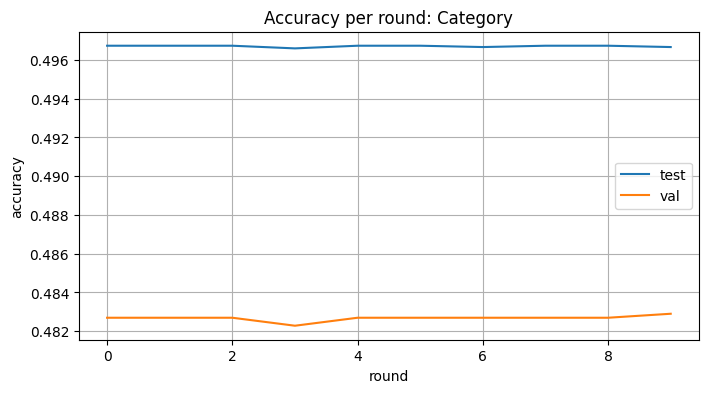

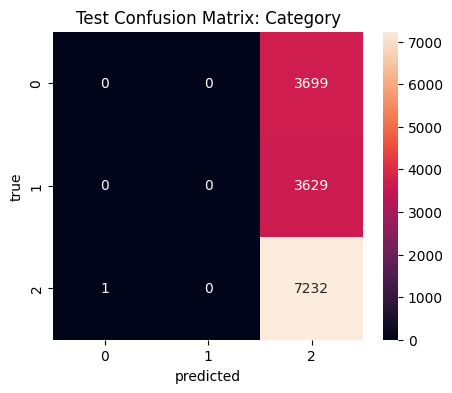

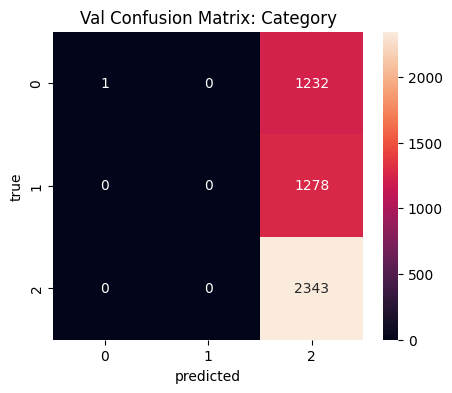

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Running ShapFed for: Motor_Symptoms
round 1 test acc: 0.3298 val acc: 0.3311
round 2 test acc: 0.3314 val acc: 0.3263
round 3 test acc: 0.331 val acc: 0.3237
round 4 test acc: 0.3323 val acc: 0.3313
round 5 test acc: 0.3233 val acc: 0.3375
round 6 test acc: 0.3279 val acc: 0.3405
round 7 test acc: 0.3283 val acc: 0.334
round 8 test acc: 0.3283 val acc: 0.3418
round 9 test acc: 0.3287 val acc: 0.3395
round 10 test acc: 0.3283 val acc: 0.3389


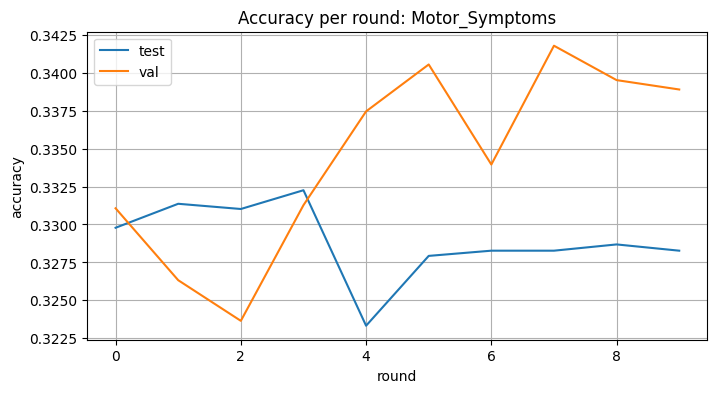

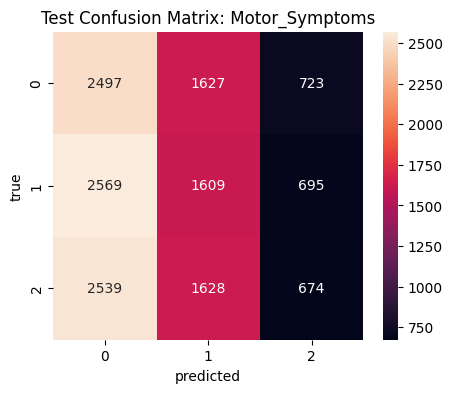

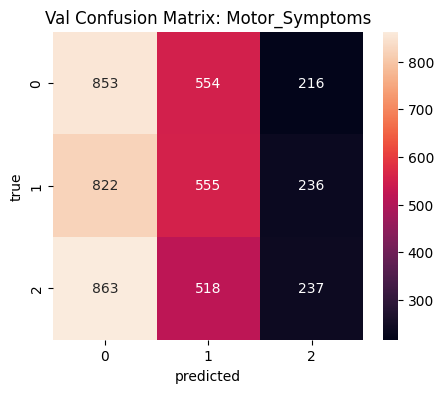


Running ShapFed for: Disease_Stage
round 1 test acc: 0.2555 val acc: 0.2476
round 2 test acc: 0.2562 val acc: 0.247
round 3 test acc: 0.2572 val acc: 0.2513
round 4 test acc: 0.255 val acc: 0.2503
round 5 test acc: 0.2554 val acc: 0.2565
round 6 test acc: 0.2553 val acc: 0.2567
round 7 test acc: 0.2521 val acc: 0.248
round 8 test acc: 0.2525 val acc: 0.2509
round 9 test acc: 0.2527 val acc: 0.2489
round 10 test acc: 0.2531 val acc: 0.2513


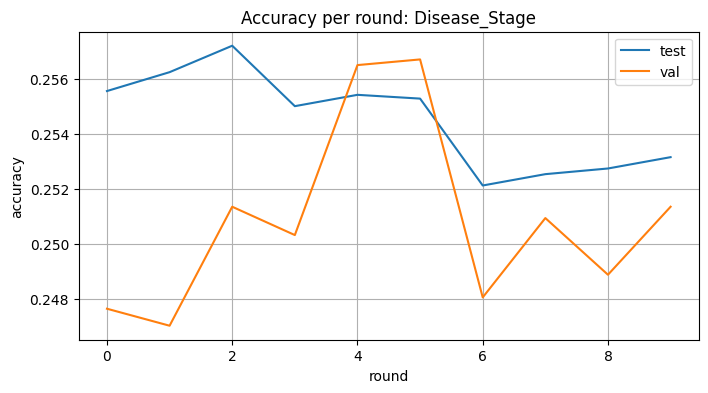

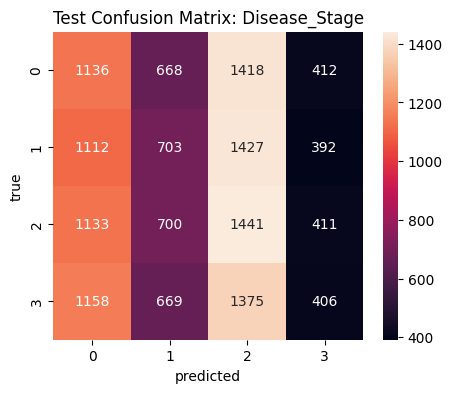

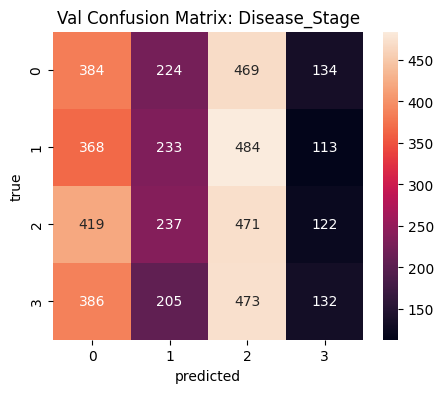


Final Comparison Table
           target  test_accuracy  test_precision  test_recall   test_f1  \
0        Category       0.496669        0.246731     0.496669  0.329685   
1  Motor_Symptoms       0.328274        0.327113     0.328274  0.308748   
2   Disease_Stage       0.253142        0.252974     0.253142  0.240947   

   val_accuracy  
0      0.482901  
1      0.338896  
2      0.251339  

Overall Test Accuracy: 0.3593617654465124
Overall Validation Accuracy: 0.35771185276747697


In [2]:
# =========================
# IMPORT REQUIRED LIBRARIES
# =========================
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# =========================
# LOAD DATASET FROM ZIP
# =========================
uploaded = files.upload()
zip_filename = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_filename, "r") as z:
    z.extractall("/content/")

csv_files = [f for f in os.listdir("/content/") if f.endswith(".csv")]
csv_path = os.path.join("/content/", csv_files[0])

df = pd.read_csv(csv_path)
print("dataset shape:", df.shape)
print(df.head())

# =========================
# BASIC PREPROCESSING
# =========================
# fill missing values
df = df.ffill()

# drop non-useful or text-heavy columns
df = df.drop(columns=[
    "Patient_ID",
    "Function",
    "Effect",
    "Gene/Factor",
    "Chromosome_Location",
    "Random_Protein_Sequence",
    "Random_Gene_Sequence"
], errors="ignore")

# encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# =========================
# MODEL DEFINITION
# =========================
def build_model(num_features, num_classes):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(num_features,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

# =========================
# FEDERATED UTILITIES
# =========================
def split_into_clients(X, y, num_clients=5):
    idx = np.arange(len(X))
    np.random.shuffle(idx)
    shards = np.array_split(idx, num_clients)
    return [(X[s], y[s]) for s in shards]

def get_weights(model):
    return [w.copy() for w in model.get_weights()]

def set_weights(model, weights):
    model.set_weights(weights)

def subtract_weights(a, b):
    return [ai - bi for ai, bi in zip(a, b)]

def add_weights(a, b):
    return [ai + bi for ai, bi in zip(a, b)]

def scale_weights(w, s):
    return [x * s for x in w]

def predict_classes(model, X):
    return np.argmax(model.predict(X, verbose=0), axis=1)

# =========================
# SHAPFED CORE LOGIC
# =========================
# accuracy is used as utility function
def utility_accuracy(model, X, y):
    preds = predict_classes(model, X)
    return accuracy_score(y, preds)

# approximate Shapley values using permutations
def shapley_weights(base_weights, updates, X_eval, y_eval, permutations=80):
    n = len(updates)
    contrib = np.zeros(n)
    temp_model = build_model(X_eval.shape[1], len(np.unique(y_eval))) # y_eval should be numpy array here

    for _ in range(permutations):
        order = np.random.permutation(n)
        w = [bw.copy() for bw in base_weights]
        set_weights(temp_model, w)
        prev_u = utility_accuracy(temp_model, X_eval, y_eval)

        for i in order:
            w = add_weights(w, updates[i])
            set_weights(temp_model, w)
            new_u = utility_accuracy(temp_model, X_eval, y_eval)
            contrib[i] += new_u - prev_u
            prev_u = new_u

    # normalize Shapley values
    contrib = np.maximum(contrib, 0)
    if contrib.sum() == 0:
        return np.ones(n) / n
    return contrib / contrib.sum()

# =========================
# VISUALIZATION FUNCTIONS
# =========================
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(title)
    plt.xlabel("predicted")
    plt.ylabel("true")
    plt.show()

def plot_accuracy_curve(test_acc, val_acc, title):
    plt.figure(figsize=(8,4))
    plt.plot(test_acc, label="test")
    plt.plot(val_acc, label="val")
    plt.title(title)
    plt.xlabel("round")
    plt.ylabel("accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# =========================
# MAIN SHAPFED TRAINING
# =========================
def run_shapfed(target):
    print("\nRunning ShapFed for:", target)

    y = df[target].astype(int)
    X = df.drop(columns=["Category","Motor_Symptoms","Disease_Stage"], errors="ignore")

    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
    X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    X_val = scaler.transform(X_val)

    # Convert y splits to numpy arrays after train_test_split
    y_train = y_train.to_numpy()
    y_test = y_test.to_numpy()
    y_val = y_val.to_numpy()

    clients = split_into_clients(X_train, y_train, num_clients=5)

    global_model = build_model(X_train.shape[1], len(np.unique(y_train))) # use y_train directly
    global_weights = get_weights(global_model)

    test_hist, val_hist = [], []

    for rnd in range(10):
        updates = []

        # local client training
        for Xc, yc in clients:
            local = build_model(X_train.shape[1], len(np.unique(y_train)))
            set_weights(local, global_weights)
            local.fit(Xc, yc, epochs=1, verbose=0)
            updates.append(subtract_weights(get_weights(local), global_weights))

        # Shapley weighting
        shap_w = shapley_weights(global_weights, updates, X_val, y_val)

        # aggregate updates
        agg = None
        for i, up in enumerate(updates):
            w_up = scale_weights(up, shap_w[i])
            agg = w_up if agg is None else add_weights(agg, w_up)

        global_weights = add_weights(global_weights, agg)
        set_weights(global_model, global_weights)

        # evaluation
        test_pred = predict_classes(global_model, X_test)
        val_pred = predict_classes(global_model, X_val)

        test_acc = accuracy_score(y_test, test_pred)
        val_acc = accuracy_score(y_val, val_pred)

        test_hist.append(test_acc)
        val_hist.append(val_acc)

        print("round", rnd+1, "test acc:", round(test_acc,4), "val acc:", round(val_acc,4))

    # plots and metrics
    plot_accuracy_curve(test_hist, val_hist, "Accuracy per round: " + target)
    plot_confusion(y_test, test_pred, "Test Confusion Matrix: " + target)
    plot_confusion(y_val, val_pred, "Val Confusion Matrix: " + target)

    return {
        "target": target,
        "test_accuracy": test_acc,
        "test_precision": precision_score(y_test, test_pred, average="weighted"),
        "test_recall": recall_score(y_test, test_pred, average="weighted"),
        "test_f1": f1_score(y_test, test_pred, average="weighted"),
        "val_accuracy": val_acc
    }

# =========================
# RUN FOR ALL 3 TARGETS
# =========================
results = []
for t in ["Category","Motor_Symptoms","Disease_Stage"]:
    results.append(run_shapfed(t))

results_df = pd.DataFrame(results)
print("\nFinal Comparison Table")
print(results_df)

print("\nOverall Test Accuracy:", results_df["test_accuracy"].mean())
print("Overall Validation Accuracy:", results_df["val_accuracy"].mean())